In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
from STiMetaD import STiMetaD

proteins = ['chignolin']
# proteins = ['chignolin']
estimator = STiMetaD(minSampleSize=10)
samples = {}
for protein in proteins:
    base_path = Path(f"../data/{protein}/output")
    colnames = ["time", "hlda", "metad.bias", "metad.acc", "rmsd"]


    results = []
    r = range(2000, 2100)

    for i in r:
        index_str = f"{i:03}"
        run_path = base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}"

        df = pd.read_csv(run_path, sep=r"\s+", comment="#", names=colnames, engine="python")

        above_threshold = df[df["rmsd"] > 0.1]
        if above_threshold.empty:
            print(f"No frame above threshold in run {index_str}")
            continue

        first_hit = above_threshold.iloc[0]
        first_hit["run"] = index_str
        time = first_hit["time"] 
        acc = first_hit["metad.acc"]
        predicted = time * acc
        first_hit["predicted"] = predicted
        
        results.append(first_hit)

    results_df = pd.DataFrame(results)

    results_df.sort_values(by="time", inplace=True)
    # print(results_df[["run", "time", "metad.acc", "metad.bias", "predicted", "rmsd", "hlda"]].tail(10).to_string(index=False))

    # print(np.array(results_df['predicted']))
    samples[protein] = results_df

    
    print(f"{protein} - MFPT (mu_s): {estimator.estimateMFPT(samples=np.array(samples[protein]['predicted'] / 100)) / 1e6}")


KeyError: 'chignolin'

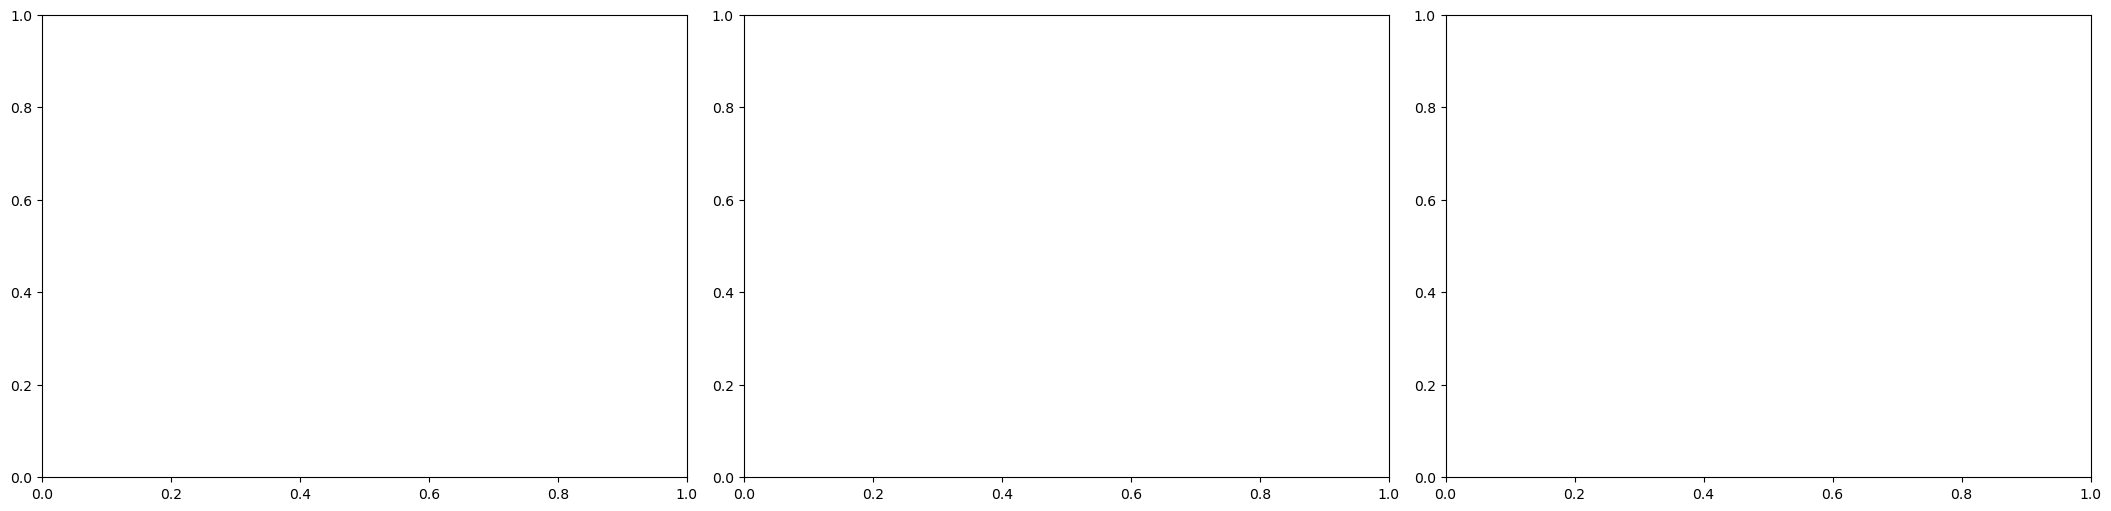

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, kstest
from scipy import optimize

# Example: proteins = ['proteinA', 'proteinB', ...]
# samples = {'proteinA': np.array([...]), 'proteinB': np.array([...]), ...}

n_cols = 3
n_rows = int(np.ceil(len(proteins) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), constrained_layout=True)

for idx, protein in enumerate(proteins):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col] if n_rows > 1 else axes[col]
    # ax.set_xscale('log')
    samples_sorted = samples[protein].sort_values(by="time")[:25]
    
    predicted = np.sort(np.array(samples_sorted["predicted"]))
    # loc, tau = expon.fit(predicted, floc=0)

    n = len(predicted)
    # survival =  np.array(
    #         [(n - i) / n for i in range(n)]
    #     )
    # ecdf = np.arange(1, n + 1) / n
    # cdf_theoretical = expon.cdf(predicted, scale=tau)

    # ax.step(predicted, ecdf, where='post', label='Empirical CDF')
    # ax.plot(predicted, cdf_theoretical, 'r--', label=f'Theoretical CDF')


    def cumulative_exp(x, tau):
        return 1 - np.exp(-x / tau)

    
    CDF = np.array([i / n for i in range(1, n + 1)])
    tau_fit = optimize.curve_fit(cumulative_exp, predicted, CDF, p0=(np.mean(predicted)))[0]


    fitted_CDF = cumulative_exp(predicted, tau_fit[0])

    ax.step(predicted, 1 - CDF, label="Empirical CDF")
    ax.plot(predicted, 1 - fitted_CDF, label=f"Fitted Exp CDF (τ = {tau_fit[0]})")

    ax.set_title(protein)
    ax.set_xlabel('Rescaled First-Passage Time')
    ax.set_ylabel('Cumulative Probability')
    ax.legend()
 
    mu = np.mean(predicted)
    sigma = np.std(predicted)
    mean_std_ratio = mu / sigma

    ks, p = estimator.iMetaDrate(samples = predicted, KStest = True)
    stats_text = (
        f"ks = {ks}, p-value: {p} \n"
        f"$\\mu/\\sigma$ = {mean_std_ratio:.3f}\n"
        f"MFPT (mu_s): {estimator.estimateMFPT(samples=np.array(samples[protein]['predicted'])) / 1e6}\n"
        f"iMetaDMFPT (mu_s): {estimator.iMetaDMFPT(samples=np.array(samples[protein]['predicted'])) / 1e6:}"
        
    )
    ax.text(0.95, 0.05, stats_text,
            transform=ax.transAxes,
            fontsize=10, va='bottom', ha='right',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))


plt.show()


In [ ]:
import numpy as np



median = np.median(samples)
median_meanln2_ratio = median / (mu * np.log(2))
print(f"median / (μ ln 2) = {median_meanln2_ratio:.3f} (should be ≈ 1)")


from scipy.stats import expon, kstest

# Fit exponential (assumes transitions start at t=0)
loc, tau = expon.fit(samples, floc=0)



NameError: name 'samples' is not defined